In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
con = sqlite3.connect(r'C:\Users\muham\Desktop\project 3,1\project 3.1\data\raw\ipl.db')

def q(sql):
    return pd.read_sql_query(sql, conn)

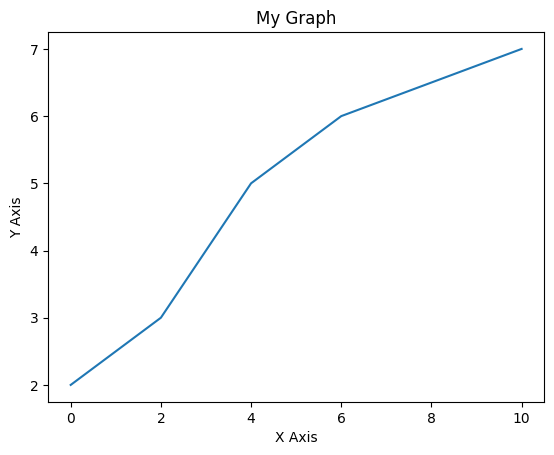

In [2]:
x=[0,2,4,6,10]
y=[2,3,5,6,7]

plt.plot(x,y)
plt.title("My Graph")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.show()

<Axes: title={'center': 'total balls in each phases'}, xlabel='DIIFERENT PHASES of inngs', ylabel='total number of balls'>

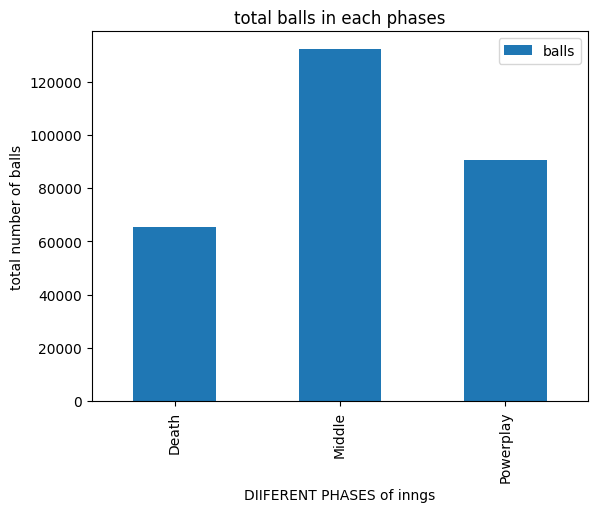

In [7]:
df=pd.read_sql("""SELECT phase, count(*) AS balls FROM v_ball GROUP BY phase;""",con)
df.plot(kind="bar",
        x="phase",
        y="balls",
        title="total balls in each phases",
        xlabel="DIIFERENT PHASES of inngs",
        ylabel="total number of balls")

In [9]:
q("""
SELECT 
    batter,
    ROUND(
        100.0 * SUM(batter_runs) / SUM(
            CASE
                WHEN is_wide_ball = 0 AND is_no_ball = 0
                THEN 1
                ELSE 0
            END
        ), 2
    ) AS strike_rate
FROM deliveries
WHERE over_number BETWEEN 15 AND 19
  AND is_super_over = 0
GROUP BY batter
ORDER BY strike_rate DESC;
""")

,batter,strike_rate
0,WG Jacks,483.33
1,DT Patil,400.00
2,KT Maphaka,400.00
3,L Wood,300.00
4,PA Reddy,300.00
...,...,...
637,Sunny Gupta,0.00
638,U Kaul,0.00
639,V Pratap Singh,0.00
640,Y Prithvi Raj,0.00


<Axes: title={'center': 'highest six scored batters total sixes'}, xlabel='six score batter', ylabel='scored total_sixes'>

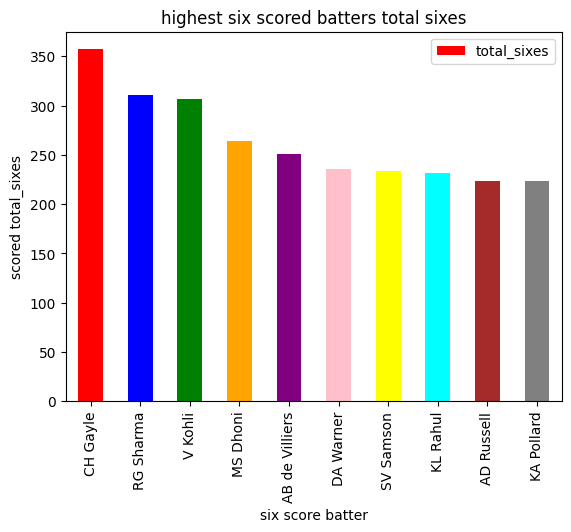

In [8]:
df=pd.read_sql("""
-- list of highest six scores in ipl history

  select batter,
         sum (case when batter_runs=6
              then 1
              else 0
              end)as total_sixes
from v_ball
group by batter
order by total_sixes desc
limit 10;
 """, con)


df.plot(kind="bar",
        x="batter",	
        y="total_sixes",
        xlabel="six score batter",
        ylabel="scored total_sixes",
        color=["red", "blue", "green", "orange", "purple",
           "pink", "yellow", "cyan", "brown", "gray"],
        title="highest six scored batters total sixes",

        )

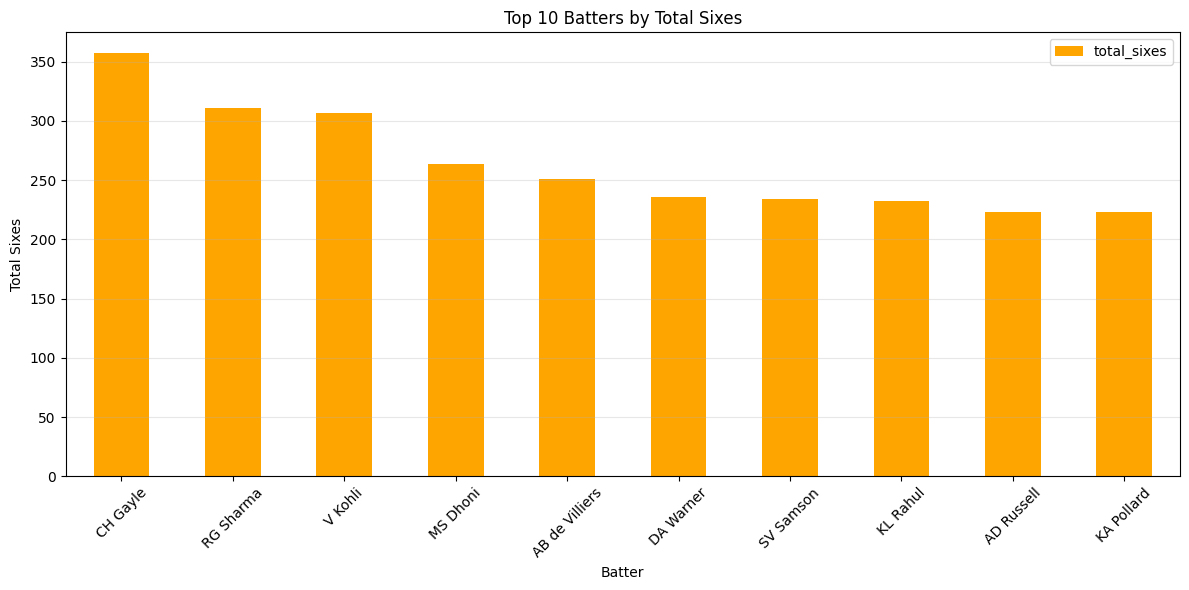

In [10]:
ac= pd.read_sql("""
SELECT 
    batter,
    SUM(
        CASE 
            WHEN batter_runs = 6 THEN 1
            ELSE 0
        END
    ) AS total_sixes
FROM v_ball
GROUP BY batter
ORDER BY total_sixes DESC
LIMIT 10;
""", con)

ac.plot(
    kind="bar",
    x="batter",
    y="total_sixes",
    title="Top 10 Batters by Total Sixes",
    xlabel="Batter",
    ylabel="Total Sixes",
    color="orange",
    figsize=(12, 6)
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

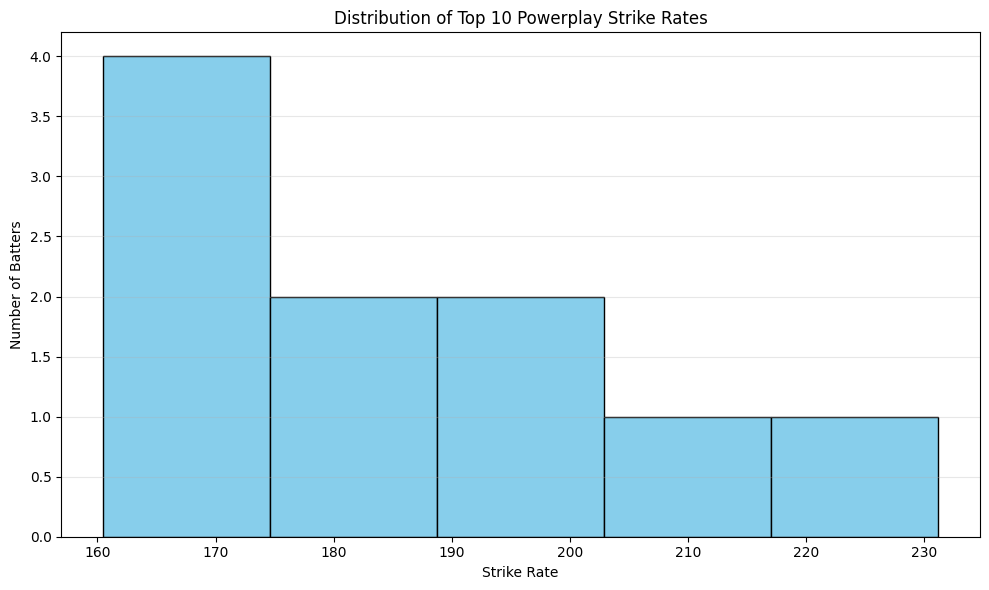

In [11]:
ad = pd.read_sql("""
SELECT 
    batter,
    SUM(batter_runs) AS runs,
    SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) AS balls,
    ROUND(
        100.0 * SUM(batter_runs) /
        SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END),
        2
    ) AS strike_rate
FROM v_ball
WHERE phase = 'Powerplay'
GROUP BY batter
HAVING SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) >= 100
ORDER BY strike_rate DESC
LIMIT 10;
""", con)

plt.figure(figsize=(10, 6))

plt.hist(
    ad["strike_rate"],
    bins=5,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Top 10 Powerplay Strike Rates")
plt.xlabel("Strike Rate")
plt.ylabel("Number of Batters")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

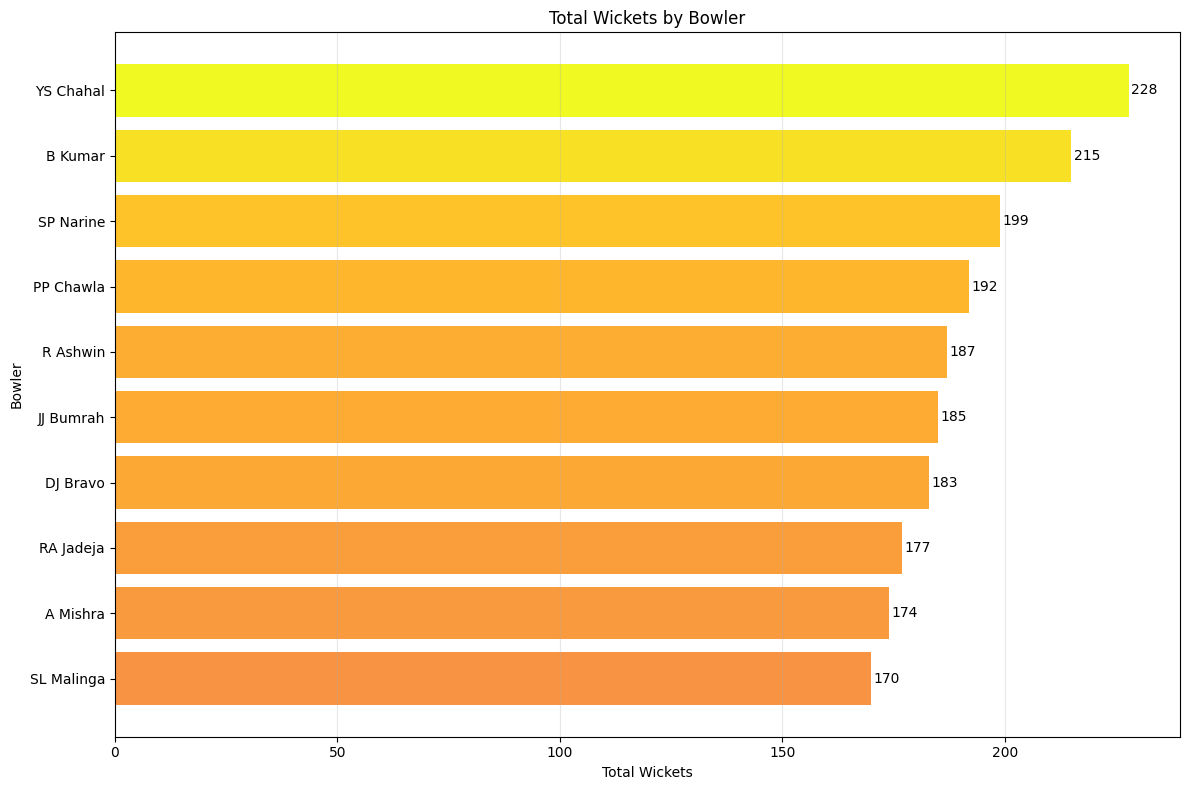

In [12]:
af= pd.read_sql("""
SELECT 
    bowler,
    SUM(bowler_wicket) AS wicket
FROM v_ball
GROUP BY bowler
ORDER BY wicket DESC
limit 10;
""", con)

plt.figure(figsize=(12, 8))

colors = plt.cm.plasma(
    af["wicket"] / af["wicket"].max()
)

bars = plt.barh(
    af["bowler"],
    af["wicket"],
    color=colors
)

plt.xlabel("Total Wickets")
plt.ylabel("Bowler")
plt.title("Total Wickets by Bowler")

plt.gca().invert_yaxis()

# Add wicket values
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

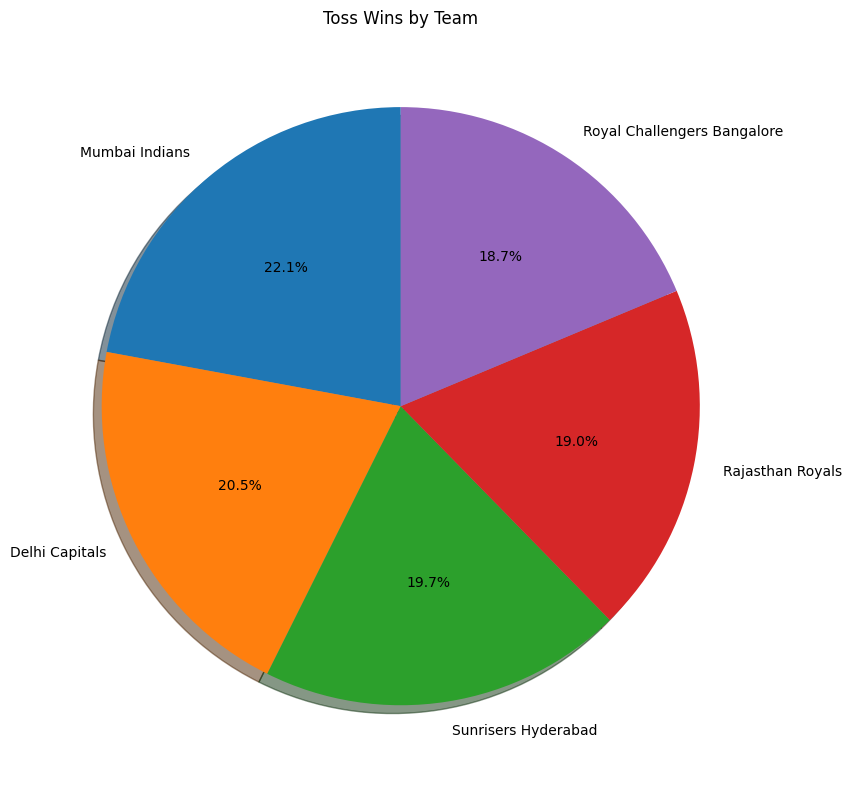

In [13]:
ag = pd.read_sql("""
SELECT
    toss_winner,
    COUNT(*) AS toss_won
FROM matches_clean
GROUP BY toss_winner
ORDER BY toss_won DESC
limit 5;
""", con)

plt.figure(figsize=(10, 8))

plt.pie(
    ag["toss_won"],
    labels=ag["toss_winner"],
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.title("Toss Wins by Team")

plt.tight_layout()
plt.show()